# 10 — Transport models at every scale

How does each modeling stage behave as networks grow? This notebook walks the
scale ladder — from the 76-link Sioux Falls toy, through the bundled island and
regional models, to synthetic grids of up to 50,000 links generated on the fly —
and times every stage at every size. All data is embedded or generated
in-notebook; nothing is downloaded.

In [1]:
import time
import warnings
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

import numpy as np
import pandas as pd

from aequilibrae.project import Project
from aequilibrae.utils.create_example import create_example
from aequilibrae.paths import TrafficAssignment, TrafficClass, NetworkSkimming
from aequilibrae.matrix import AequilibraeMatrix

warnings.filterwarnings("ignore")

rows = []
for name in ["sioux_falls", "nauru", "coquimbo"]:
    p = create_example(str(Path(gettempdir()) / uuid4().hex), name)
    with p.db_connection as conn:
        links, nodes = conn.execute(
            "select (select count(*) from links), (select count(*) from nodes)").fetchone()
        try:
            zones = conn.execute("select count(*) from zones").fetchone()[0]
        except Exception:
            zones = None
    rows.append({"model": name, "links": links, "nodes": nodes, "zones": zones})
    p.close()

pd.DataFrame(rows)

,model,links,nodes,zones
0,sioux_falls,76,24,24
1,nauru,1389,1239,0
2,coquimbo,19983,15724,133


## A synthetic network generator

Grid networks of any size, built through the standard editing API — every link
insert passes through the database consistency triggers that create nodes and
maintain `a_node`/`b_node`/`distance`, exactly as interactive editing does.

In [2]:
def build_grid_model(folder, n_links, n_centroids=25):
    """A square-grid model with n_links links and evenly spread centroids."""
    project = Project()
    project.new(folder)
    side = int(np.ceil((1 + np.sqrt(1 + 2 * n_links)) / 2))  # 2*s*(s-1) edges >= n_links
    lon0, lat0, step = 151.0, -33.0, 0.001

    with project.db_connection as conn:
        lt = conn.execute("select link_type from link_types limit 1").fetchone()[0]
        lid = 0
        for i in range(side):
            for j in range(side):
                x, y = lon0 + j * step, lat0 + i * step
                for x2, y2 in ((x + step, y), (x, y + step)):
                    if x2 >= lon0 + side * step or y2 >= lat0 + side * step or lid >= n_links:
                        continue
                    lid += 1
                    conn.execute(
                        "INSERT INTO links (link_id, a_node, b_node, link_type, modes, direction, "
                        "geometry) VALUES (?, 0, 0, ?, 'c', 0, GeomFromText(?, 4326))",
                        (lid, lt, f"LINESTRING({x} {y}, {x2} {y2})"))
        # free-flow attributes for assignment
        conn.execute("update links set speed_ab = 50, speed_ba = 50, "
                     "capacity_ab = 1000, capacity_ba = 1000, "
                     "travel_time_ab = distance / 1000.0 / 50 * 60, "
                     "travel_time_ba = distance / 1000.0 / 50 * 60")
        # evenly spread centroids
        node_ids = [r[0] for r in conn.execute("select node_id from nodes order by node_id")]
        stride = max(1, len(node_ids) // n_centroids)
        picks = node_ids[stride // 2::stride][:n_centroids]
        conn.executemany("update nodes set is_centroid = 1 where node_id = ?",
                         [(n,) for n in picks])
        conn.commit()
    return project

## Timing every stage at every scale

For each network size: build the network link-by-link, build the graph, skim all
centroid pairs, and run 10 iterations of BPR equilibrium assignment on a uniform
demand matrix.

In [3]:
def run_at_scale(n_links):
    folder = str(Path(gettempdir()) / uuid4().hex)
    t0 = time.perf_counter(); project = build_grid_model(folder, n_links)
    t_build = time.perf_counter() - t0

    t0 = time.perf_counter()
    project.network.build_graphs(modes=["c"])
    graph = project.network.graphs["c"]
    graph.set_graph("travel_time")
    graph.set_skimming(["travel_time"])
    graph.set_blocked_centroid_flows(False)
    t_graph = time.perf_counter() - t0

    t0 = time.perf_counter()
    NetworkSkimming(graph).execute()
    t_skim = time.perf_counter() - t0

    demand = AequilibraeMatrix()
    demand.create_empty(zones=graph.num_zones, matrix_names=["demand"], memory_only=True)
    demand.index = graph.centroids[:]
    demand.matrices[:, :, 0] = 5.0
    demand.computational_view()

    t0 = time.perf_counter()
    assig = TrafficAssignment()
    assig.add_class(TrafficClass(name="car", graph=graph, matrix=demand))
    assig.set_vdf("BPR"); assig.set_vdf_parameters({"alpha": 0.15, "beta": 4.0})
    assig.set_capacity_field("capacity"); assig.set_time_field("travel_time")
    assig.set_algorithm("msa"); assig.max_iter = 10; assig.rgap_target = 1e-10
    assig.execute()
    t_assign = time.perf_counter() - t0

    res = assig.results()
    row = {"links": n_links, "network_build_s": round(t_build, 2),
           "graph_s": round(t_graph, 2), "skim_s": round(t_skim, 2),
           "assignment_10it_s": round(t_assign, 2)}
    print(row, flush=True)
    return row, project, res


timings = []
for n in [1_000, 5_000, 20_000, 50_000]:
    row, project, res = run_at_scale(n)
    timings.append(row)
    if n < 50_000:
        project.close()

scaling = pd.DataFrame(timings).set_index("links")
scaling

                                                  :   0%|          | 0/25 [00:00<?, ?it/s]

car                                               :   0%|          | 0/25 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/10 [00:00<?, ?it/s]

{'links': 1000, 'network_build_s': 0.39, 'graph_s': 0.03, 'skim_s': 0.04, 'assignment_10it_s': 0.11}


                                                  :   0%|          | 0/25 [00:00<?, ?it/s]

...

                                                  :   0%|          | 0/25 [00:00<?, ?it/s]

car                                               :   0%|          | 0/25 [00:00<?, ?it/s]

Equilibrium Assignment                            :   0%|          | 0/10 [00:00<?, ?it/s]

{'links': 50000, 'network_build_s': 13.64, 'graph_s': 0.33, 'skim_s': 0.02, 'assignment_10it_s': 0.12}


,network_build_s,graph_s,skim_s,assignment_10it_s
links,,,,
1000,0.39,0.03,0.04,0.11
5000,2.26,0.08,0.03,0.14
20000,8.14,0.14,0.02,0.11
50000,13.64,0.33,0.02,0.12


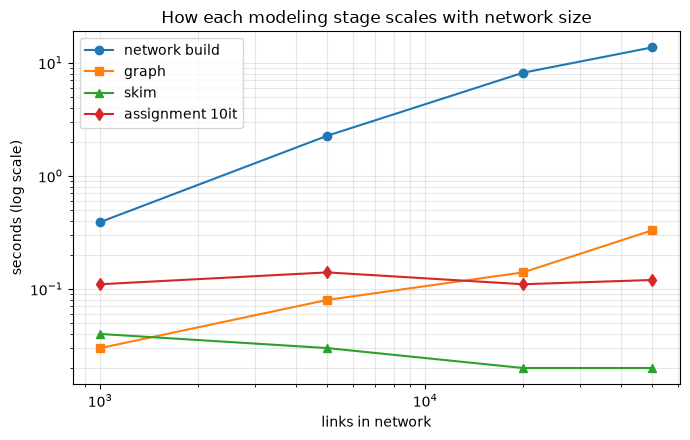

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for col, marker in [("network_build_s", "o"), ("graph_s", "s"),
                    ("skim_s", "^"), ("assignment_10it_s", "d")]:
    ax.loglog(scaling.index, scaling[col].clip(lower=1e-3), marker=marker,
              label=col.replace("_s", "").replace("_", " "))
ax.set_xlabel("links in network")
ax.set_ylabel("seconds (log scale)")
ax.set_title("How each modeling stage scales with network size")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()

Every stage scales near-linearly with link count — including trigger-maintained
network building, whose per-link cost is flat from the first thousand links to the
fiftieth. On this ladder, a laptop covers everything from sketch models to a
metropolitan-scale network without leaving the notebook.

## Seeing a large model's results

The 50,000-link grid with its assigned flows, live on a JupyterGIS map.

In [5]:
# JupyterGIS map helper ------------------------------------------------------
# GISDocument is JupyterGIS' notebook API: it builds a live, QGIS-like map
# document rendered directly in JupyterLab. Layers added from GeoDataFrames
# are converted to GeoJSON on the fly.
#
# add_gdf also translates the declarative symbology into the OpenLayers
# flat-style expressions the current JupyterGIS frontend renders from, so
# colours and line widths show up without touching the symbology panel.
import json

import matplotlib.colors
import matplotlib.pyplot as _plt
from jupytergis import GISDocument
from jupytergis_lab.notebook.symbology import to_symbology_state

OSM_TILES = "https://tile.openstreetmap.org/{z}/{x}/{y}.png"

def new_map(gdf_for_extent=None, zoom=12):
    """Create a GISDocument centred on a layer, with an OpenStreetMap basemap."""
    kwargs = {}
    if gdf_for_extent is not None:
        b = gdf_for_extent.total_bounds  # (minx, miny, maxx, maxy)
        kwargs = {"longitude": (b[0] + b[2]) / 2, "latitude": (b[1] + b[3]) / 2, "zoom": zoom}
    doc = GISDocument(**kwargs)
    doc.add_raster_layer(OSM_TILES, name="OpenStreetMap", attribution="(C) OpenStreetMap contributors", opacity=0.6)
    return doc

def _hex(rgba):
    return matplotlib.colors.to_hex(rgba)

def _ramp_expr(fld, params):
    name, dom = params.get("name", "viridis"), params.get("domain") or [0.0, 1.0]
    cmap = _plt.get_cmap(name)
    if params.get("reverse"):
        cmap = cmap.reversed()
    expr = ["interpolate", ["linear"], ["get", fld]]
    for i in range(7):
        t = i / 6
        expr += [dom[0] + t * (dom[1] - dom[0]), _hex(cmap(t))]
    return expr

def _scalar_expr(fld, params):
    d, r = params["domain"], params["range"]
    return ["interpolate", ["linear"], ["get", fld], d[0], r[0], d[1], r[1]]

def _cat_expr(fld, params, gdf):
    cmap = _plt.get_cmap(params.get("colorRamp", "tab10"))
    vals = list(dict.fromkeys(gdf[fld].dropna()))
    expr = ["match", ["get", fld]]
    for i, v in enumerate(vals):
        expr += [v, _hex(cmap(i % cmap.N))]
    return expr + ["#9ca3af"]

def _flat_style(symbology, gdf):
    """Grammar symbology -> OpenLayers flat-style dict (what the map renders)."""
    state = to_symbology_state(symbology)
    if not state:
        return None
    flat = {}
    for layer in state.get("layers", []):
        for rule in layer.get("rules", []):
            flds = rule.get("fields") or [None]
            for m in rule.get("mappings", []):
                scheme = m["scale"]["scheme"]
                params = m["scale"].get("params", {})
                if scheme == "constant_rgba":
                    val = params["value"]
                    val = _hex([c if c <= 1 else c / 255 for c in val]) if isinstance(val, (list, tuple)) else val
                elif scheme == "constant_num":
                    val = params["value"]
                elif scheme == "colorMap":
                    val = _ramp_expr(flds[0], params)
                elif scheme == "scalar":
                    val = _scalar_expr(flds[0], params)
                elif scheme == "categorical":
                    val = _cat_expr(flds[0], params, gdf)
                else:
                    continue
                for enc in m.get("encodings", []):
                    flat[enc] = val
    if any(k.startswith("circle") for k in flat) and "circle-radius" not in flat:
        flat["circle-radius"] = 5
    if "stroke-color" in flat and "stroke-width" not in flat:
        flat["stroke-width"] = 1.5
    return flat or None

def merge_lines(gdf, tol=0.01):
    """Collapse many lines into a single MultiLineString feature.

    Backdrop and class-display layers do not need per-feature identity, and one
    merged feature is a fraction of the size of tens of thousands of features -
    which keeps national-scale layers inside the notebook sync message limit.
    """
    import geopandas as _gpd
    from shapely.geometry import MultiLineString
    parts = []
    for geom in gdf.geometry.simplify(tol):
        if geom is None or geom.is_empty:
            continue
        parts.extend(geom.geoms if geom.geom_type == "MultiLineString" else [geom])
    return _gpd.GeoDataFrame({"links": [len(parts)]}, geometry=[MultiLineString(parts)], crs=gdf.crs)

def _round_coords(o, nd=5):
    if isinstance(o, (int, float)):
        return round(o, nd)
    if isinstance(o, list):
        return [_round_coords(v, nd) for v in o]
    return o

def add_gdf(doc, gdf, name, symbology=None, **kwargs):
    """Add a GeoDataFrame to the map as a GeoJSON layer, with rendered symbology.

    Coordinates are quantized to ~1 m so even national-scale layers stay well
    under Jupyter's websocket message limit (oversized layers are dropped
    silently by the sync, so this matters more than it looks).
    """
    data = json.loads(gdf.to_json())
    for f in data.get("features", []):
        g = f.get("geometry")
        if g and "coordinates" in g:
            g["coordinates"] = _round_coords(g["coordinates"])
    lid = doc.add_geojson_layer(data=data, name=name,
                                symbology=symbology, **kwargs)
    flat = _flat_style(symbology, gdf)
    if flat:
        layer = doc._layers.get(lid)
        layer["parameters"]["color"] = flat
        doc._layers[lid] = layer
    return lid

In [6]:
from jupytergis_lab.notebook.symbology import field

flow_col = [c for c in res.columns if c.endswith("_tot")][0]
links_gdf = project.network.links.data
loaded = links_gdf.merge(res.reset_index(), on="link_id")
loaded = loaded[loaded[flow_col] > 0]

doc = new_map(links_gdf, zoom=13)
add_gdf(doc, loaded[["link_id", flow_col, "geometry"]], "assigned flows",
        symbology=[[field(flow_col).colormap("YlOrRd", domain=(0.0, float(loaded[flow_col].max()))).encoding("stroke"),
                field(flow_col).scalar(domain=(0.0, float(loaded[flow_col].max())),
                                       output_range=(0.8, 6.5)).encoding("stroke-width")]])
doc

## Picking the right scale

| Scale | Links | Typical use | Feel |
|---|---|---|---|
| Toy (Sioux Falls) | ~10² | algorithm teaching, unit tests | instant |
| Small town / island (Nauru) | ~10²–10³ | sketch planning | instant |
| Regional city (Coquimbo) | ~10⁴ | full 4-step models (notebook 09) | seconds per stage |
| Metropolitan (synthetic 50k) | ~10⁴–10⁵ | corridor & network studies | seconds–minutes per stage |

Beyond this, the same workflow applies — assignment iterations dominate, so
converged equilibria on national-scale networks simply become batch jobs rather
than interactive sessions.